# Exploratory data analysis

### Data description in student_mat.csv

Factor descriptions:
- school - school the student attends (binary: GP - Gabriel Pereira or MS - Mousinho da Silveira).
- gender - student's gender (binary: F - female or M - male).
- age - student's age (numeric: from 15 to 22).
- address - type of area the student lives in (binary: U - urban or R - rural).
- famsize - family size (binary: LE3 - «less or equal to 3» or GT3 - «greater than 3»).
- Pstatus - parents' cohabitation status (binary: T - «living together» or A - «apart»).
- Medu - mother's education (numeric: 0 - «none», 1 - «primary education» (4th grade), 2 - «5th to 9th grade», 3 - «secondary education» or 4 - «higher education»).
- Fedu - father's education (numeric: 0 - «none», 1 - «primary education» (4th grade), 2 - «5th to 9th grade», 3 - «secondary education» or 4 - «higher education»).
- Mjob - mother's job (categorical: teacher - «teacher», health - «health care», services - «civil services», at_home - «at home» or other - «other»).
- Fjob - father's job (categorical: teacher - «teacher», health - «health care», services - «civil services», at_home - «at home» or other - «other»).
- reason - reason for choosing this school (categorical: home - «close to home», reputation - «school reputation», course - «course preference» or other - «other»).
- guardian - student's guardian (categorical: mother - «mother», father - «father» or other - «other»).
- traveltime - home to school travel time (numeric: 1 - «<15 min», 2 - «15 to 30 min», 3 - «30 min to 1 hour» or 4 - «>1 hour»).
- studytime - weekly study time (numeric: 1 - «<2 hours», 2 - «2 to 5 hours», 3 - «5 to 10 hours» or 4 - «>10 hours»).
- failures - number of past subject failures (numeric: from 0 to 3).
- schoolsup - additional educational support (binary: yes - yes or no - no).
- famsup - family educational support (binary: yes - yes or no - no).
- paid - extra paid classes within the course subject (binary: yes - yes or no - no).
- activities - extracurricular activities (binary: yes - yes or no - no).
- nursery - attended nursery school (binary: yes - yes or no - no).
- higher - wants to take higher education (binary: yes - yes or no - no).
- internet - Internet access at home (binary: yes - yes or no - no).
- romantic - with a romantic relationship (binary: yes - yes or no - no).
- famrel - quality of family relationships (numeric: from 1 - «very bad» to 5 - «excellent»).
- freetime - free time after school (numeric: from 1 - «very low» to 5 - «very high»).
- goout - going out with friends (numeric: from 1 - «very low» to 5 - «very high»).
- health - current health status (numeric: from 1 - «very bad» to 5 - «very good»).
- absences - number of school absences (numeric: from 0 to 93).
- G1 - first period grade (numeric: from 0 to 20).

Target variable:
- G3 - final grade (numeric: from 0 to 20).

### Loading and initial exploration of educational data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from category_encoders.target_encoder import TargetEncoder
from sklearn.model_selection import train_test_split
from IPython.display import display

In [2]:
# Reading data
sns.set(rc={'figure.figsize': (11.7, 8.27)})
student_dataset = pd.read_csv('../../data/student_mat.csv')

print(f'Data dimensions: {student_dataset.shape}')
print('\nFirst 5 rows of data:')
display(student_dataset.head())

Data dimensions: (395, 30)

First 5 rows of data:


,school,gender,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,3,4,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,3,10,7,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,5,2,15,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,5,4,6,10


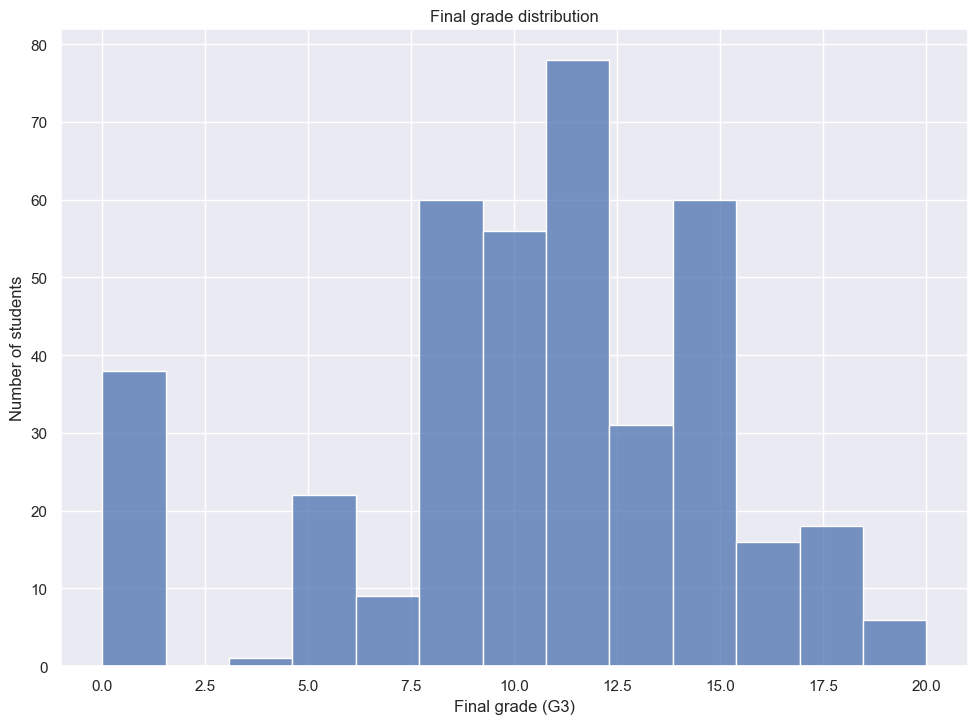

In [3]:
# Visualization of student final grade distribution
sns.histplot(student_dataset['G3'])
plt.title('Final grade distribution')
plt.xlabel('Final grade (G3)')
plt.ylabel('Number of students')
plt.show()

We observe many final grades equal to zero. For deeper analysis of zero final grades, we examine the first period performance (G1) of these students. This helps determine whether the poor performance was predictable or sudden.

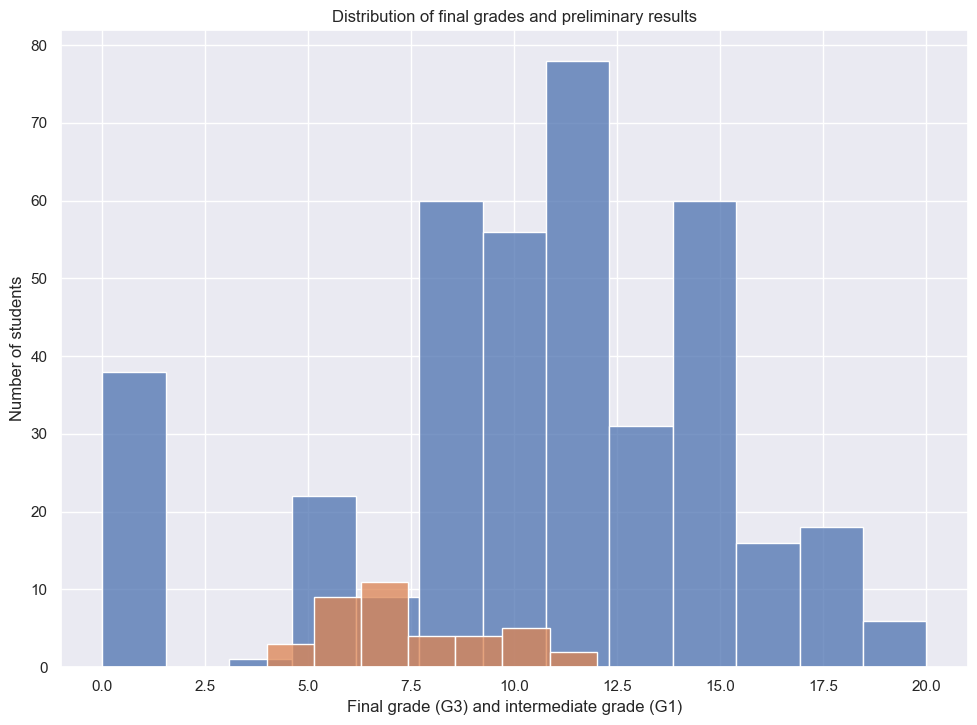

In [4]:
sns.histplot(student_dataset['G3'])
sns.histplot(student_dataset[student_dataset['G3'] == 0]['G1'])
plt.title('Distribution of final grades and preliminary results')
plt.xlabel('Final grade (G3) and intermediate grade (G1)')
plt.ylabel('Number of students')
plt.show()

A discrepancy was found: students with zero final grades showed noticeable performance in the first period. This indicates data anomalies, likely related to input errors or special circumstances. To build a more accurate model, such cases were excluded from the analysis.

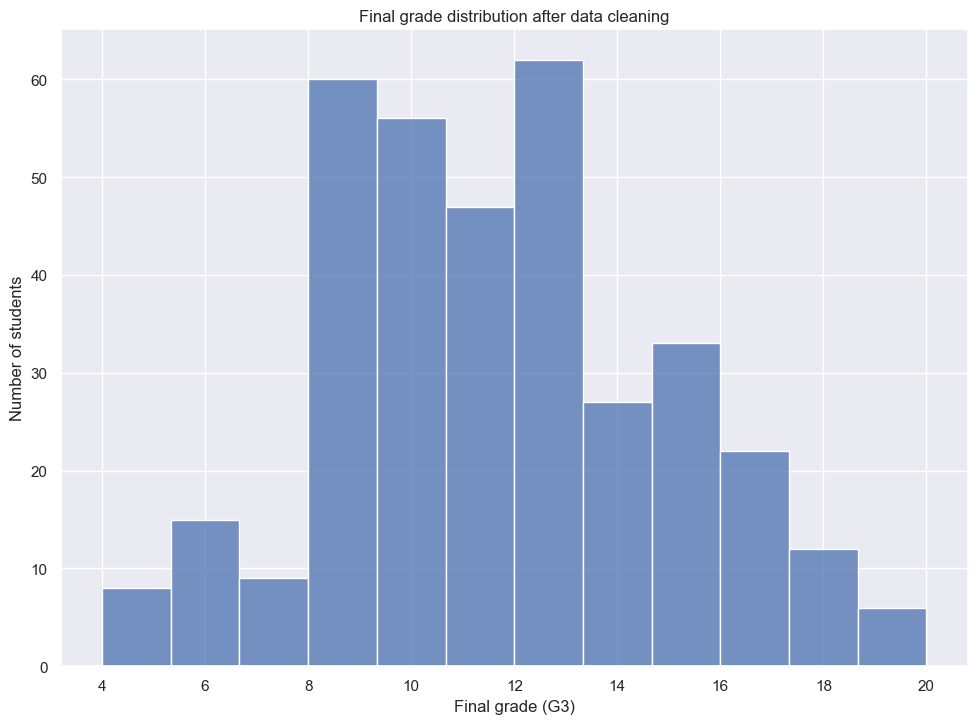

In [5]:
filtered_data = student_dataset[student_dataset['G3'] != 0]
sns.histplot(filtered_data['G3'])
plt.title('Final grade distribution after data cleaning')
plt.xlabel('Final grade (G3)')
plt.ylabel('Number of students')
plt.show()

### Formation of training and test sets

In [6]:
predictors = filtered_data.drop(columns=['G3'])
target_variable = filtered_data['G3']

# Since there is too little data, the test set will contain only 50 values, and
# a validation set will not be created
x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
    predictors, target_variable, test_size=50, random_state=52)

print(f'Training set size: {x_train_split.shape[0]}')
print(f'Test set size: {x_test_split.shape[0]}')

Training set size: 307
Test set size: 50


### Analysis of relationships between numerical factors and final grade

In [7]:
training_data_with_target = x_train_split.copy(deep=True)
training_data_with_target['G3'] = y_train_split
numeric_features = training_data_with_target.select_dtypes(
    include=['int64', 'float64'])
correlation_analysis = numeric_features.corr()['G3']

print('Correlation analysis:')
display(correlation_analysis.to_frame(''))

Correlation analysis:


,
age,-0.124842
Medu,0.156956
Fedu,0.133866
traveltime,-0.070539
studytime,0.122987
failures,-0.306787
famrel,0.074646
freetime,0.001826
goout,-0.172547
health,-0.075481


Correlation analysis results allow us to identify the three most significant performance factors:

- G1 - exceptionally strong positive factor (r = 0.89)
- Failures - significant negative factor (r = -0.31)
- Absences - moderate negative factor (r = -0.23)

These factors will carry maximum informational value for building the prediction model.

In [8]:
# Selection of statistically significant correlations
significant_correlations = correlation_analysis[
    (correlation_analysis >= 0.1) | (correlation_analysis <= -0.1)]

print('Statistically significant correlations:')
display(significant_correlations.sort_values(ascending=False).to_frame(''))

Statistically significant correlations:


,
G3,1.000000
G1,0.889723
Medu,0.156956
Fedu,0.133866
studytime,0.122987
age,-0.124842
goout,-0.172547
absences,-0.232230
failures,-0.306787


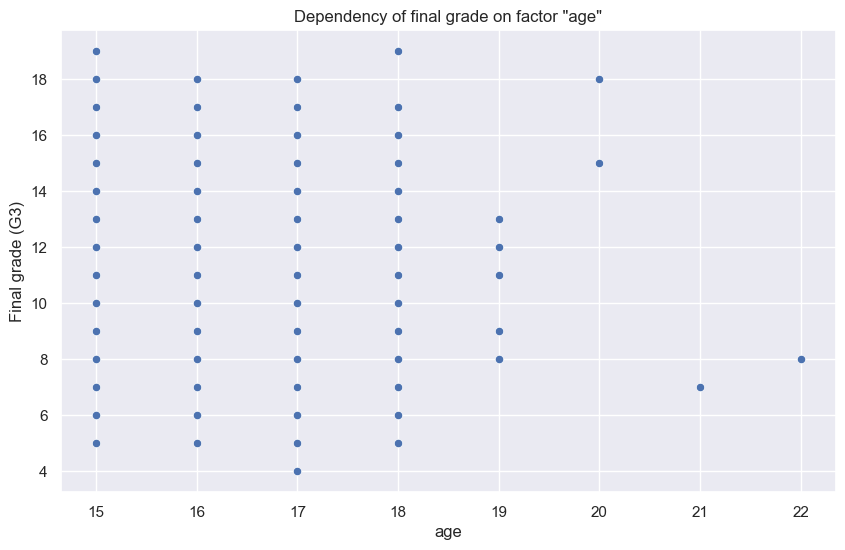

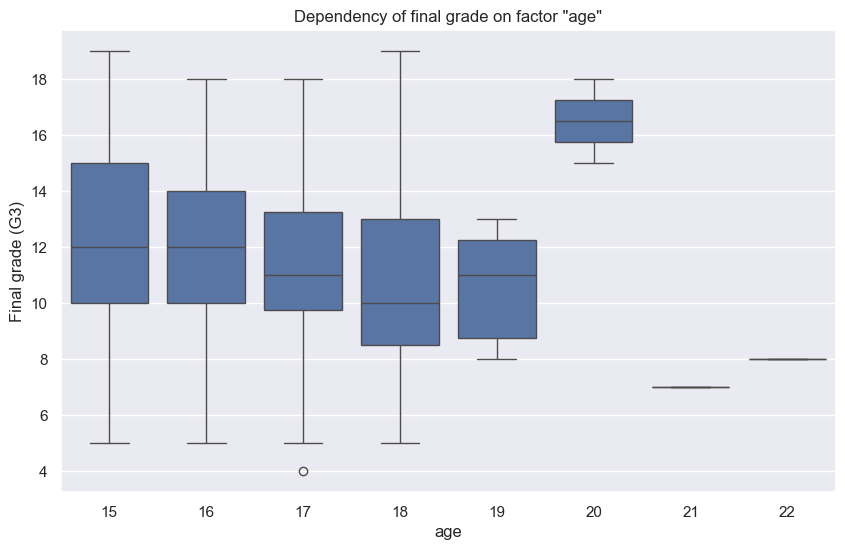

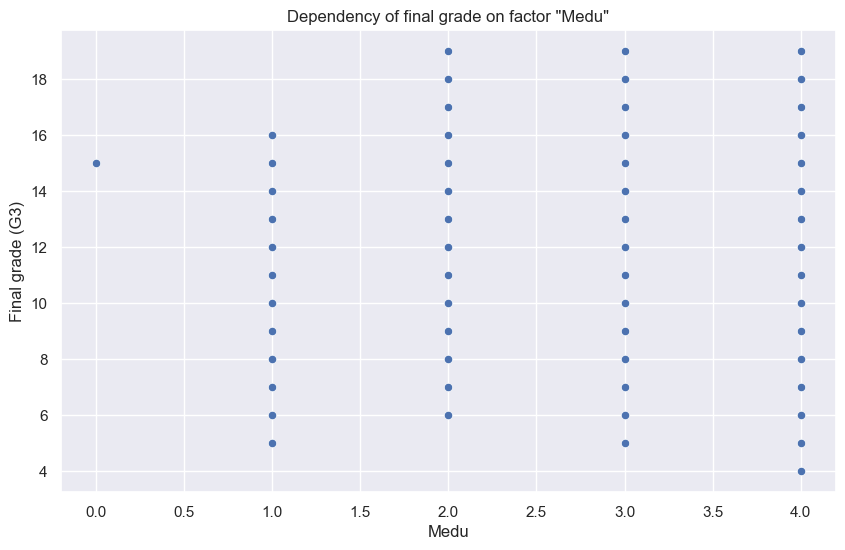

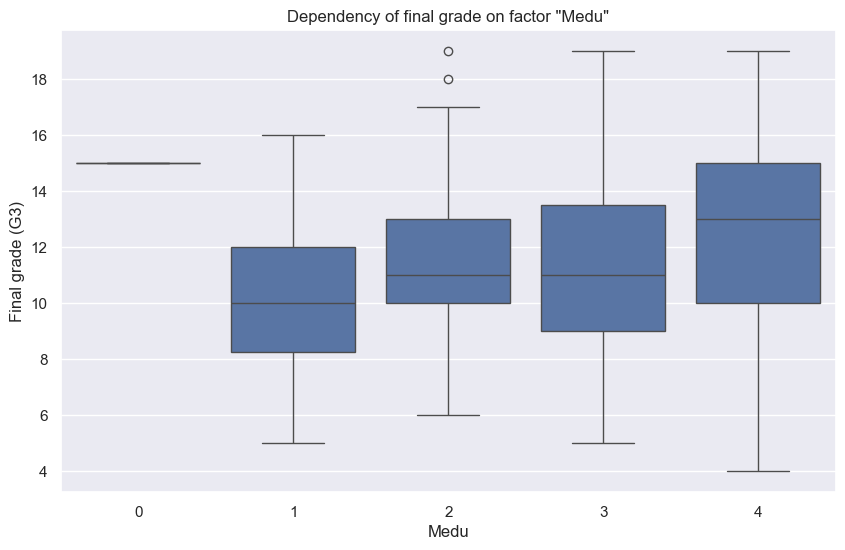

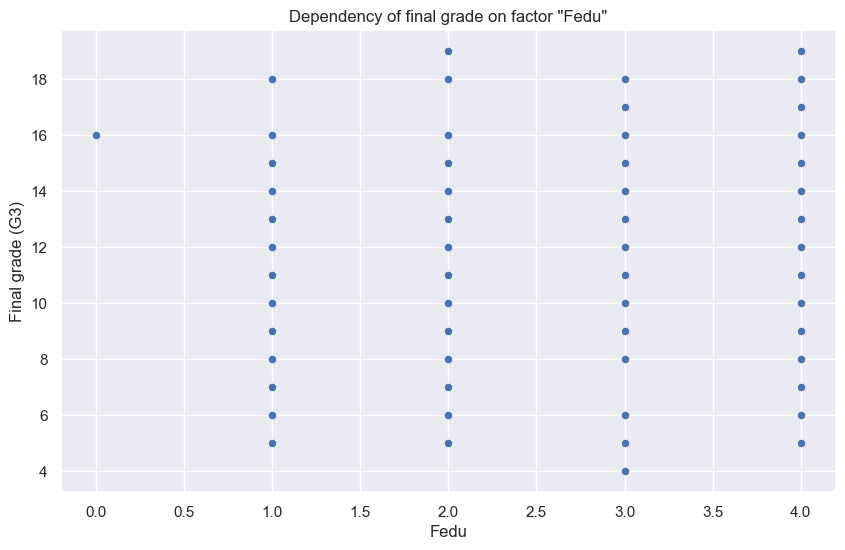

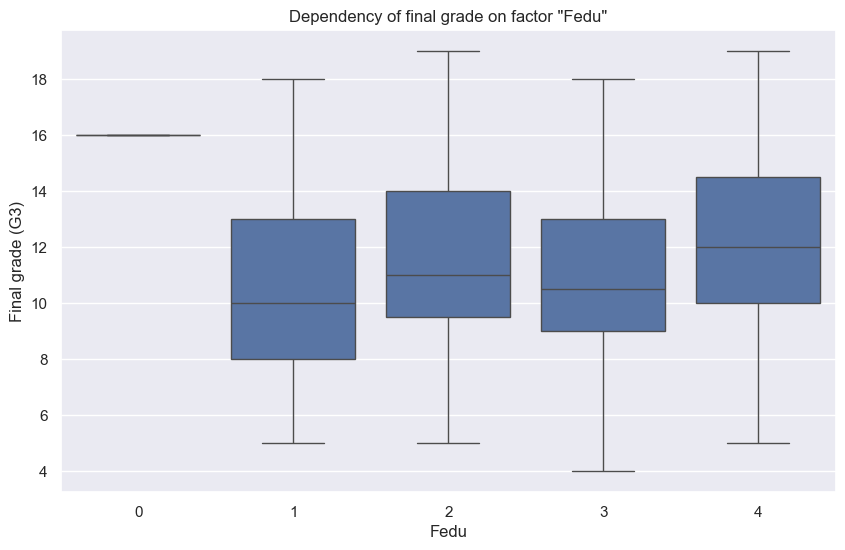

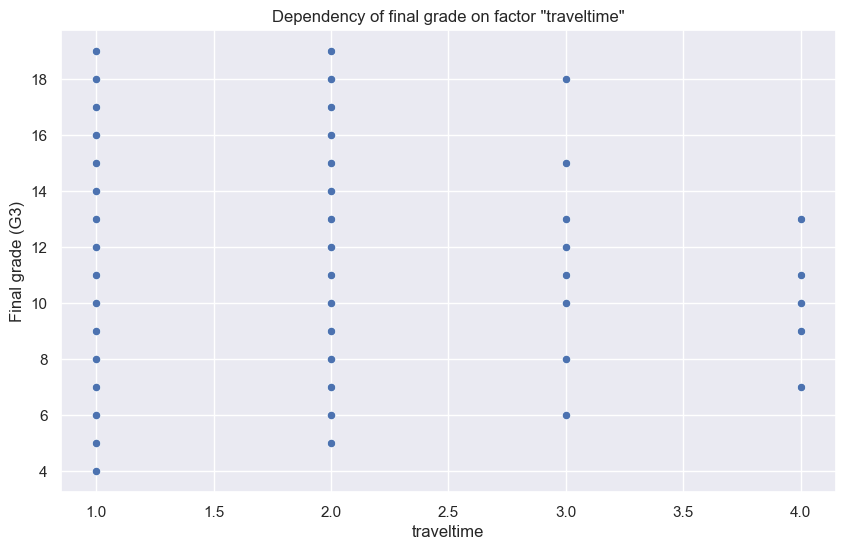

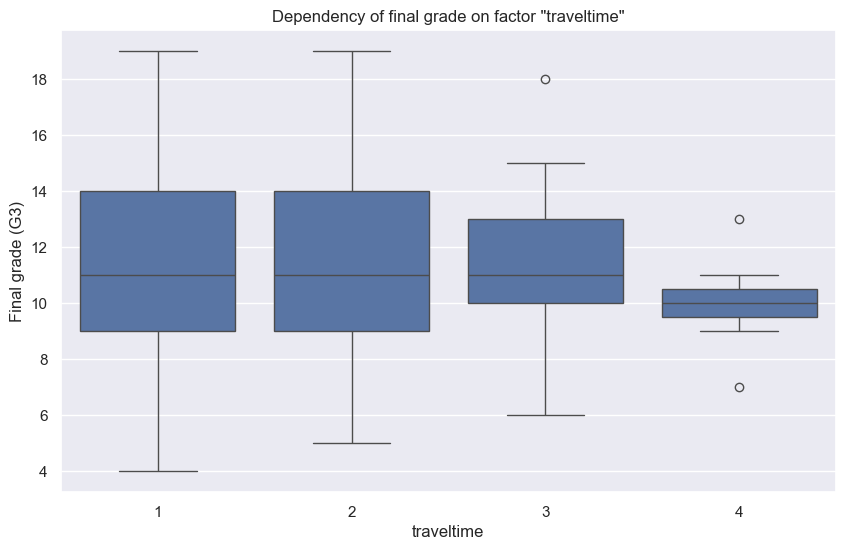

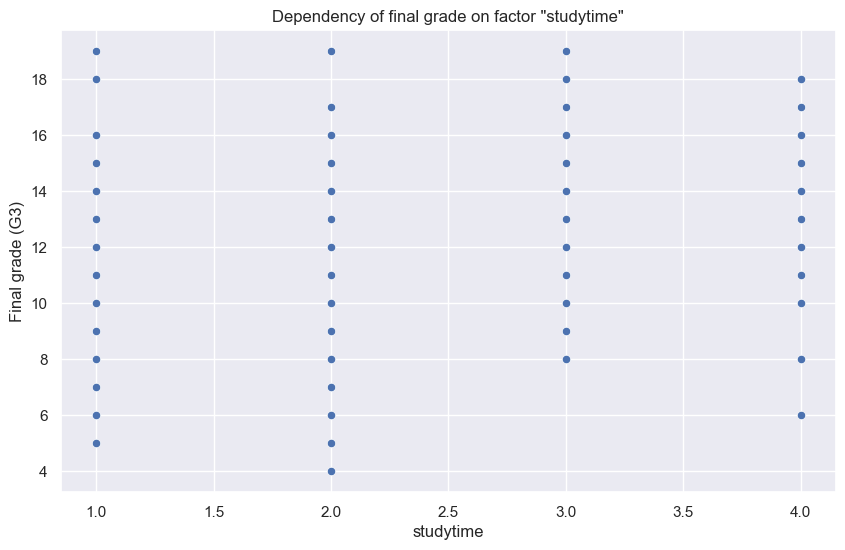

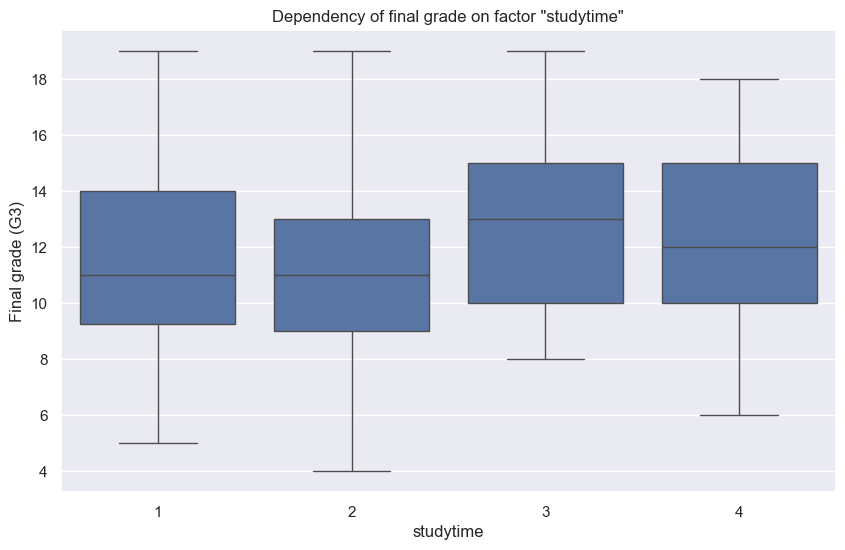

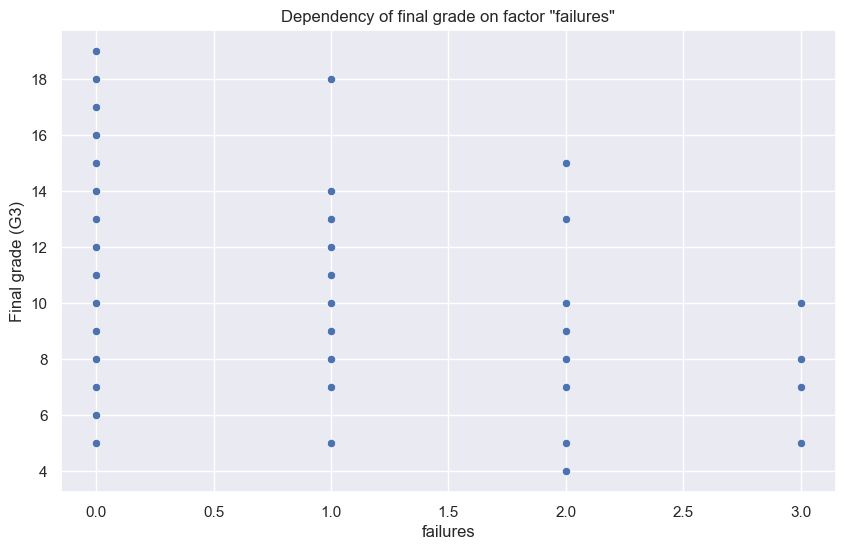

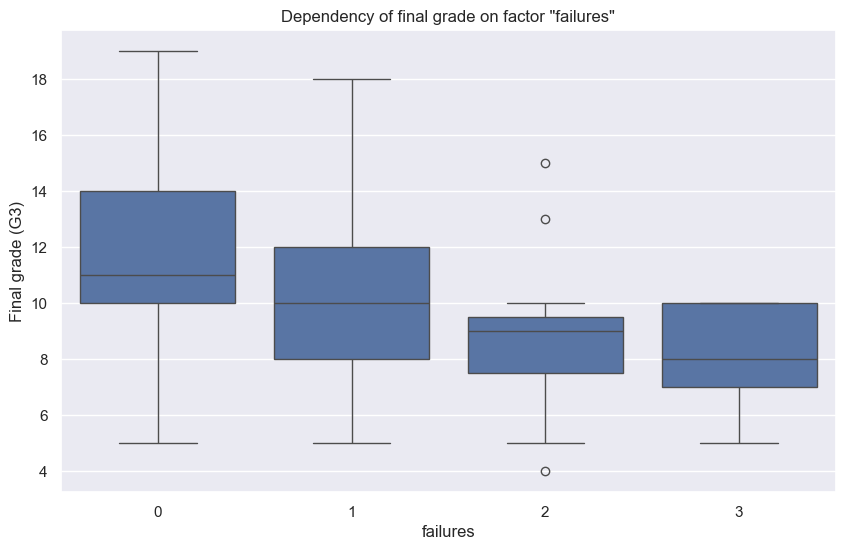

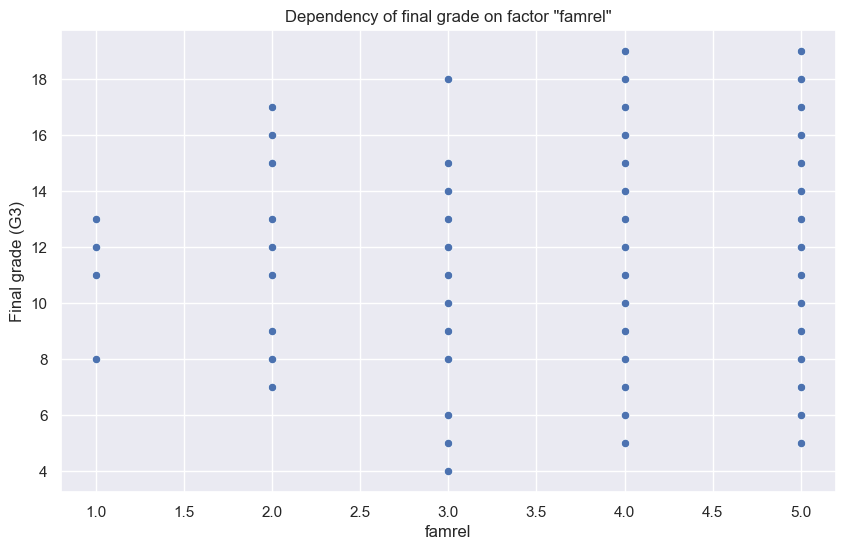

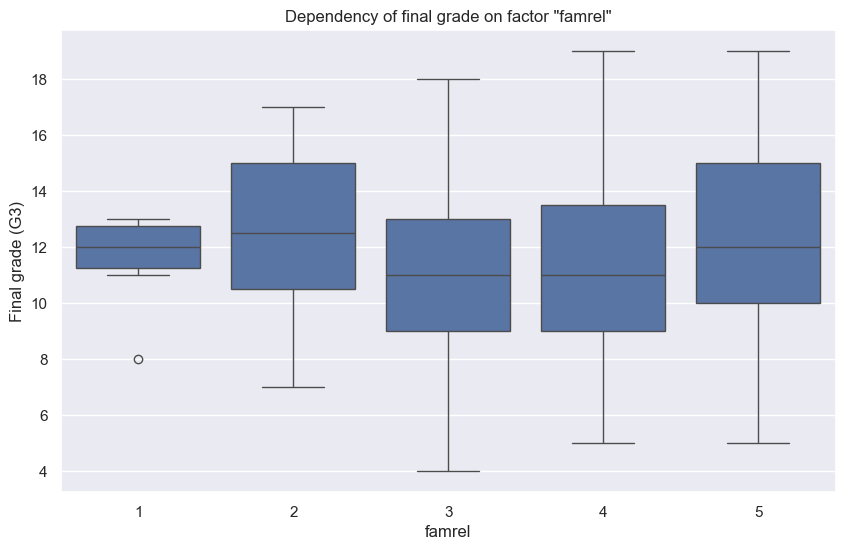

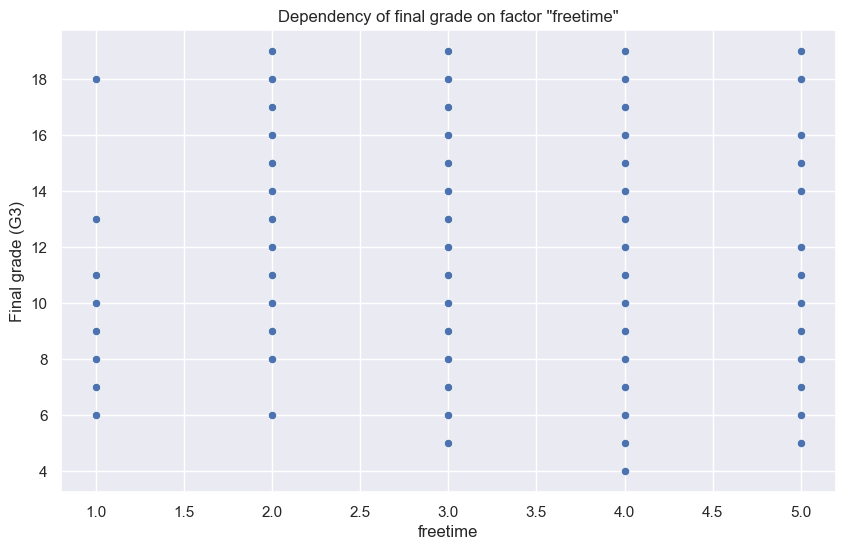

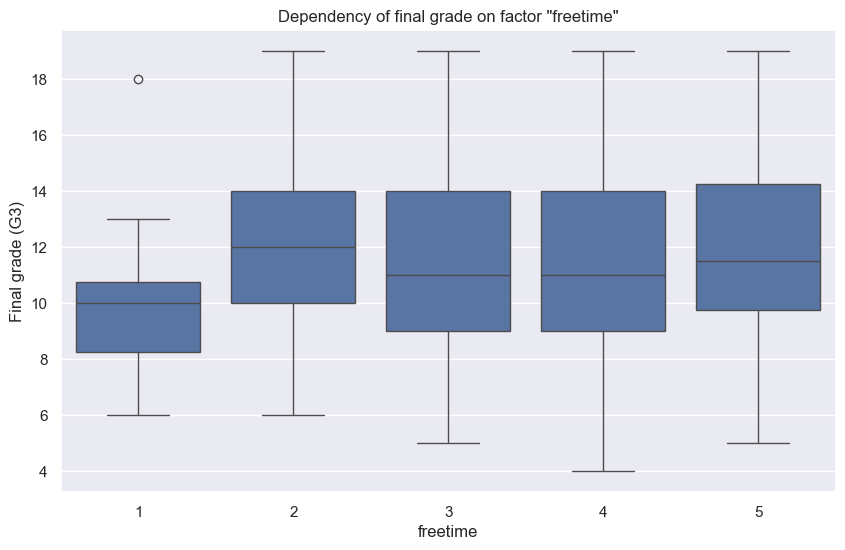

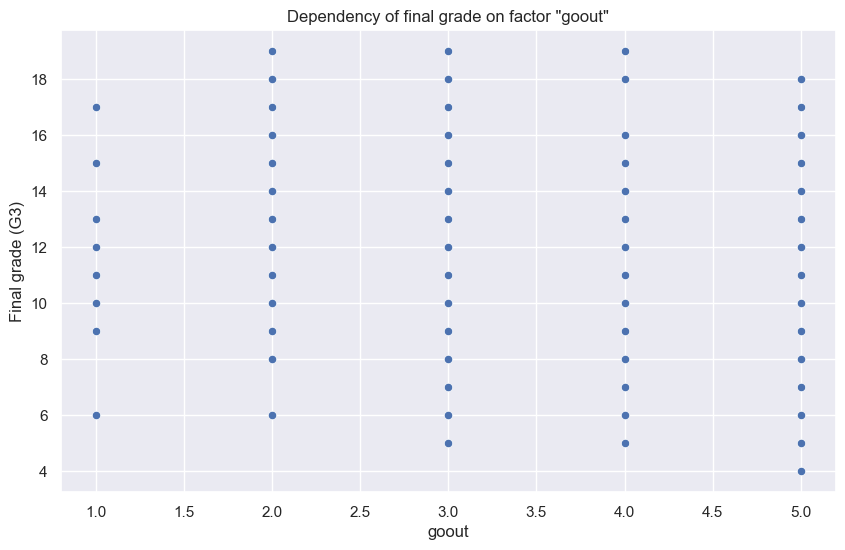

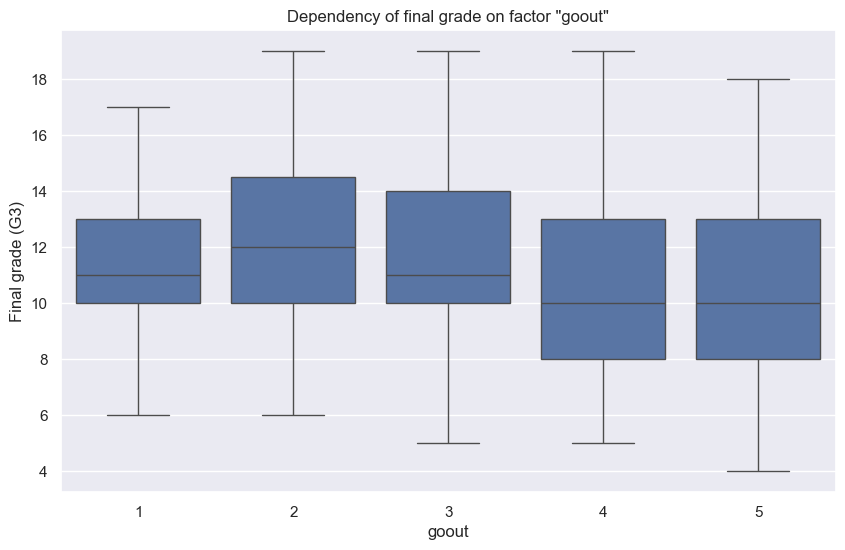

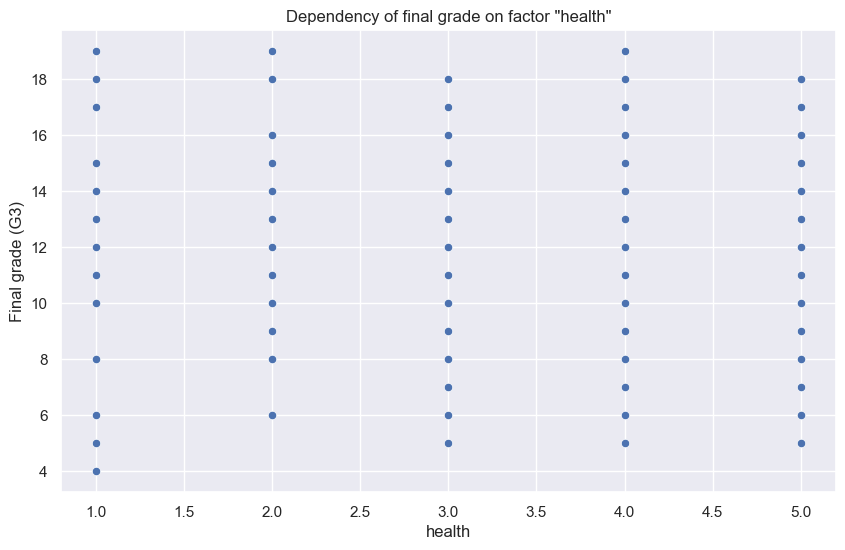

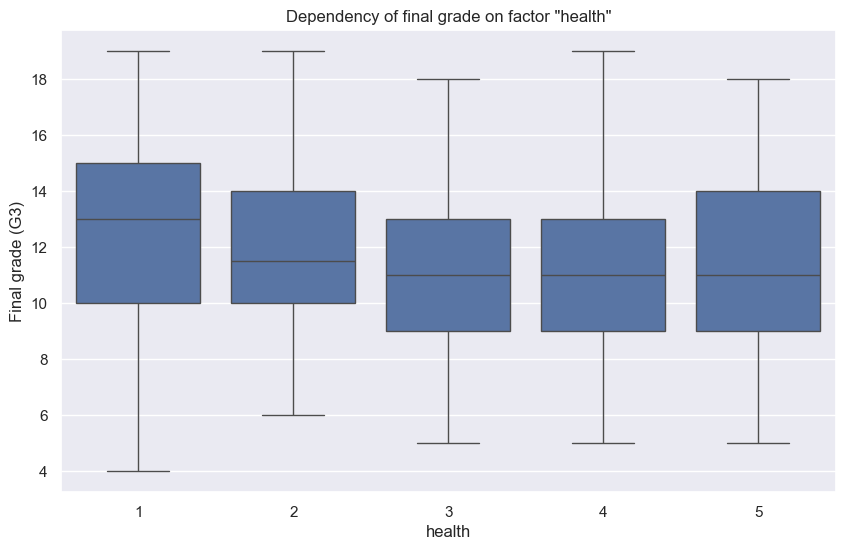

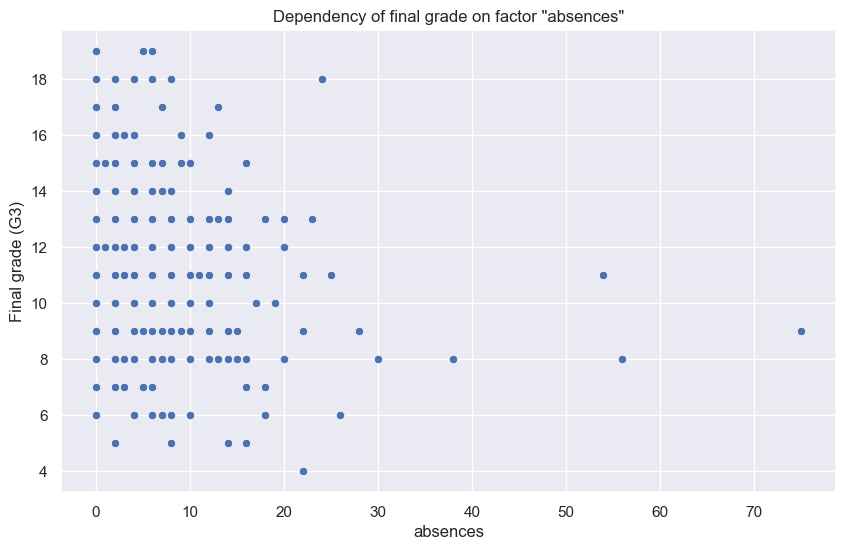

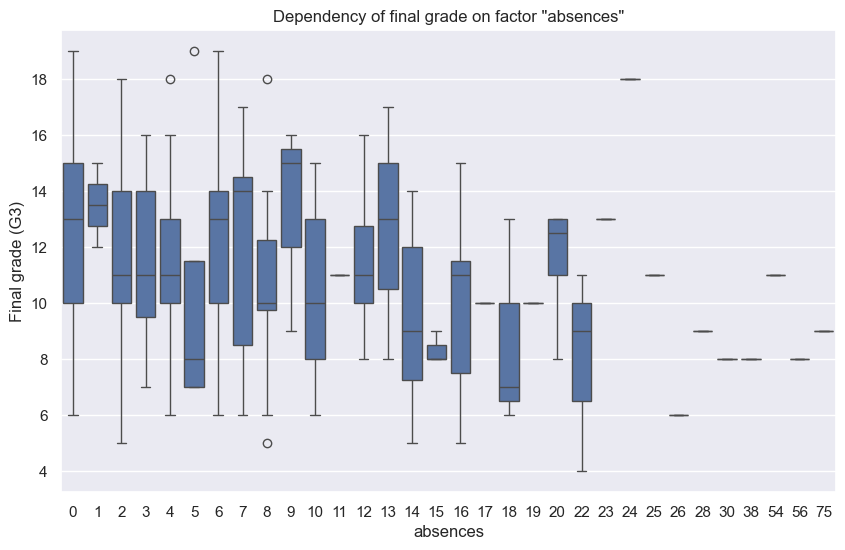

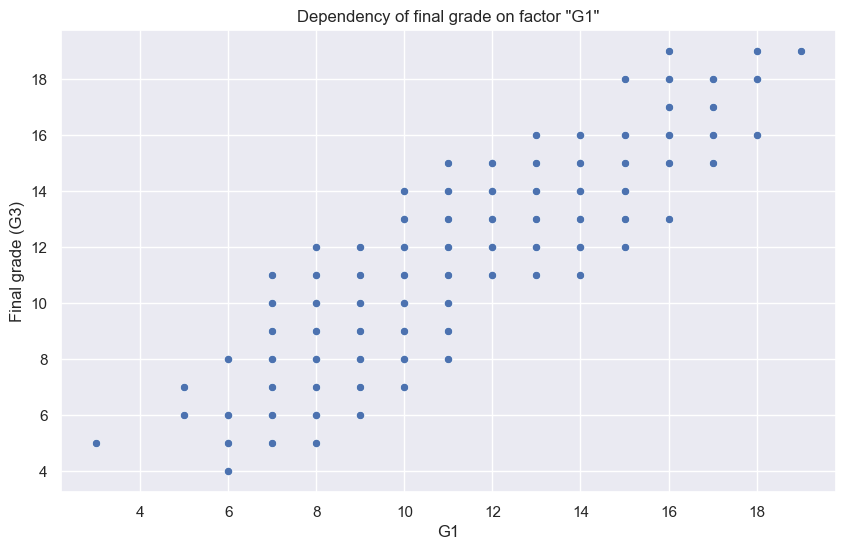

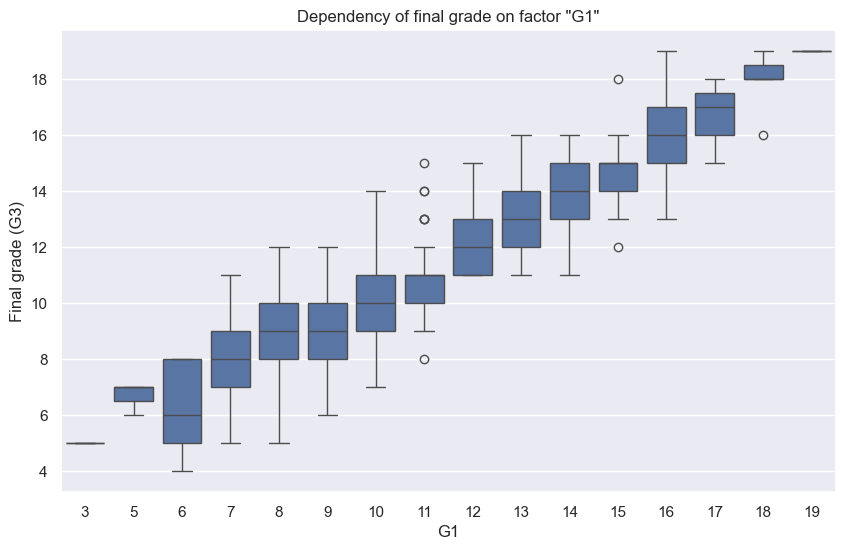

In [9]:
# Graph analysis for variables with high correlation
selected_numeric_features = correlation_analysis.drop('G3').index.tolist()
for variable in selected_numeric_features:
    # First dependency graph
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=training_data_with_target[variable],
                    y=training_data_with_target['G3'])
    plt.title(f'Dependency of final grade on factor "{variable}"')
    plt.xlabel(variable)
    plt.ylabel('Final grade (G3)')
    plt.show()

    # Second dependency graph
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=training_data_with_target[variable],
                y=training_data_with_target['G3'])
    plt.title(f'Dependency of final grade on factor "{variable}"')
    plt.xlabel(variable)
    plt.ylabel('Final grade (G3)')
    plt.show()

Key patterns identified through visual analysis:

1. Age ("age") - Negative trend observed: as age increases, performance generally decreases. Anomaly: sharp performance spike at age 20, likely an outlier requiring additional verification.
2. Parental Education ("Medu", "Fedu") - Clear positive correlation between mother's education level ("Medu") and academic results. Higher maternal education correlates with better student performance on average.
3. Academic Failures ("failures") - Strong dependency found: students with fewer failed subjects demonstrate significantly higher final grades. This indicates systematic nature of academic performance.
4. Free Time ("freetime") - Students with minimal free time show poorer results. This may indicate time management issues or excessive academic workload.
5. First Period Grade ("G1") - Most significant predictor with clear linear dependency. High first period results practically guarantee high final grades.

Other examined factors don't show substantial patterns.

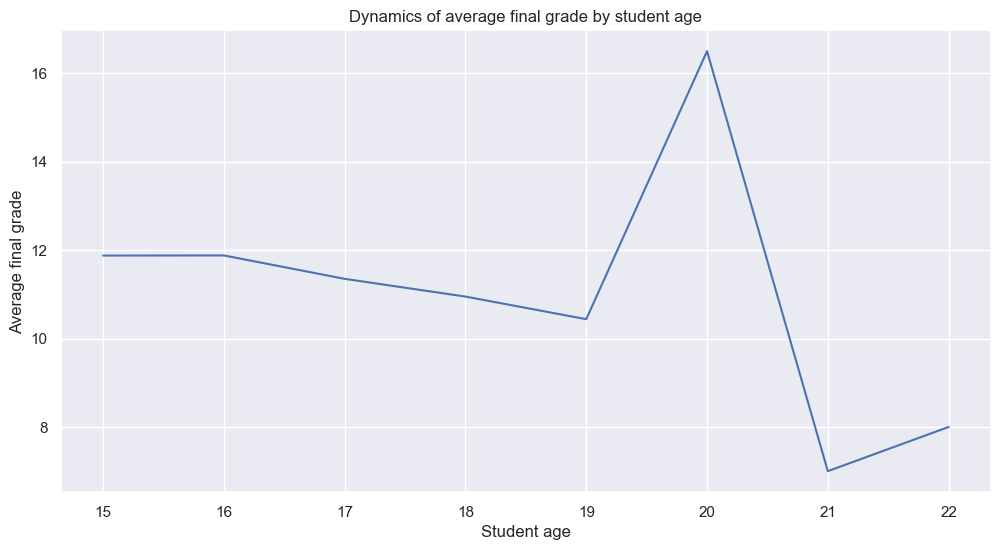

In [10]:
# Analysis of age dynamics of academic performance
plt.figure(figsize=(12, 6))
sns.lineplot(x=training_data_with_target['age'],
             y=training_data_with_target['G3'], estimator='mean',
             errorbar=None)
plt.title('Dynamics of average final grade by student age')
plt.xlabel('Student age')
plt.ylabel('Average final grade')
plt.grid(True)
plt.show()

Graph analysis shows weak relationship between age and academic performance. However, clear anomalies are observed - sharp performance spikes at ages 20 and 21 that don't follow the general trend. Given the insignificance of the main dependency, these points are likely statistical outliers.

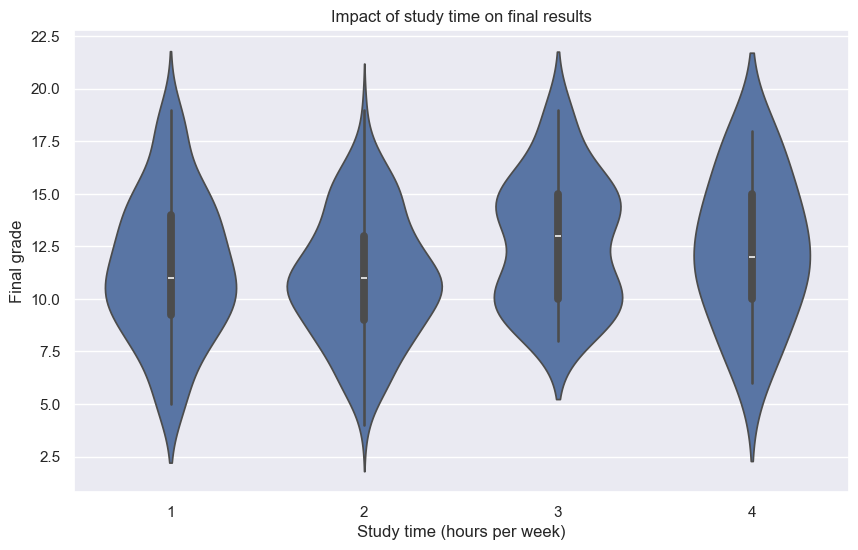

In [11]:
# Comprehensive analysis of study time and its impact on results
plt.figure(figsize=(10, 6))
sns.violinplot(x=training_data_with_target['studytime'],
               y=training_data_with_target['G3'])
plt.title('Impact of study time on final results')
plt.xlabel('Study time (hours per week)')
plt.ylabel('Final grade')
plt.show()

We can observe that the relationship between study time and final grade is statistically insignificant.

In [12]:
# Derivation of the most informative numerical factors
print('Selected numerical features for modeling:')
display(selected_numeric_features)

Selected numerical features for modeling:


['age',
 'Medu',
 'Fedu',
 'traveltime',
 'studytime',
 'failures',
 'famrel',
 'freetime',
 'goout',
 'health',
 'absences',
 'G1']

### Analysis of relationships between categorical factors and final grade

In [13]:
categorical_features = [
    'school', 'gender', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

def analyze_categorical_influence(data, categorical_cols, target_col='G3'):
    """Analyzes the influence of categorical features on the target variable"""
    influence_metrics = []

    for feature in categorical_cols:
        # Aggregation of mean target variable values by categories
        aggregated_data = data.groupby(
            feature, as_index=False).agg({target_col: 'mean'})

        # Calculation of statistical metrics
        target_values = aggregated_data[target_col].values
        influence_metrics.append({
            'feature': feature,
            'range': np.max(target_values) - np.min(target_values)
        })
    return pd.DataFrame(influence_metrics)

In [14]:
# Analysis of categorical factors influence
categorical_analysis_df = analyze_categorical_influence(
    training_data_with_target, categorical_features)

# Sorting by influence range (highest influence at top)
categorical_analysis_df = categorical_analysis_df.sort_values(
    'range', ascending=False)

print('Analysis of categorical factors influence on final grade:')
display(categorical_analysis_df.reset_index(drop=True))

Analysis of categorical factors influence on final grade:


,feature,range
0,Fjob,2.255952
1,Mjob,2.220917
2,schoolsup,2.212977
3,higher,1.795395
4,school,1.067437
5,reason,0.778428
6,address,0.759845
7,internet,0.751384
8,guardian,0.739899
9,romantic,0.531836


Analysis of feature variability revealed the most significant factors: "Fjob", "Mjob", "schoolsup", "higher" and "school". Their high value range indicates substantial data differences, making these variables most informative for model prediction. Other features like "nursery" or "famsize" show low variability and will likely have insignificant impact on results.

In [15]:
# Automatic selection of most significant features
significant_categorical_features = categorical_analysis_df[
    categorical_analysis_df['range'] > 1.0]['feature'].tolist()

print('Significant categorical factors:')
print(significant_categorical_features)

Significant categorical factors:
['Fjob', 'Mjob', 'schoolsup', 'higher', 'school']


### Data preparation for modeling

In [16]:
# Encoding significant categorical features
def encode_categorical_features(data, features_to_encode, target_col='G3'):
    """Performs target encoding for specified categorical features"""
    encoders = {}
    encoded_data = data.copy(deep=True)

    for feature in features_to_encode:
        encoder = TargetEncoder()
        encoder.fit(data[feature], data[target_col])
        encoded_data[f'{feature}_encoded'] = encoder.transform(data[feature])
        encoders[feature] = encoder
    return encoded_data, encoders

training_data_encoded, feature_encoders = encode_categorical_features(
    training_data_with_target, significant_categorical_features)

# Forming final feature set for modeling
final_features = selected_numeric_features + [
    f'{feature}_encoded' for feature in significant_categorical_features
]
x_train_processed = training_data_encoded[final_features].copy(deep=True)

# Data scaling
data_scaler = MinMaxScaler()
data_scaler.fit(x_train_processed)
x_train_scaled = data_scaler.transform(x_train_processed)

# Converting data from matrix back to dataframe
x_train_scaled_df = pd.DataFrame(
    x_train_scaled,
    columns=x_train_processed.columns,
    index=x_train_processed.index
)

# Test set preparation
test_data_with_target = x_test_split.copy(deep=True)
test_data_with_target['G3'] = y_test_split

# Applying target encoding to categorical features using
# encoders trained on training data
test_data_encoded = test_data_with_target.copy(deep=True)
for feature in significant_categorical_features:
    # Using encoder trained on training data
    encoder = feature_encoders[feature]
    test_data_encoded[f'{feature}_encoded'] = encoder.transform(
        test_data_with_target[feature])

# Forming final feature set for test data
x_test_processed = test_data_encoded[final_features].copy(deep=True)

# Scaling test data using scaler trained on training data
x_test_scaled = data_scaler.transform(x_test_processed)

# Converting data from matrix back to dataframe
x_test_scaled_df = pd.DataFrame(
    x_test_scaled,
    columns=x_test_processed.columns,
    index=x_test_processed.index
)

### Output of prepared data

In [17]:
print('Encoded training data (first 5 rows):')
display(x_train_processed.head())

print('\nScaled training data (first 5 rows):')
display(x_train_scaled_df.head())

Encoded training data (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,Fjob_encoded,Mjob_encoded,schoolsup_encoded,higher_encoded,school_encoded
391,17,3,1,2,1,0,2,4,5,2,3,14,11.454583,11.848348,11.812977,11.564626,10.715385
267,18,4,4,2,2,0,4,3,4,4,8,12,11.244048,11.603237,11.812977,11.564626,11.610294
235,16,3,2,2,3,0,5,3,3,2,10,11,11.244048,11.213616,11.812977,11.564626,11.610294
19,16,4,3,1,1,0,3,1,3,5,4,8,11.244048,12.504080,11.812977,11.564626,11.610294
189,17,1,2,1,2,0,3,1,3,3,4,8,11.244048,11.213616,11.812977,11.564626,11.610294



Scaled training data (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,Fjob_encoded,Mjob_encoded,schoolsup_encoded,higher_encoded,school_encoded
391,0.285714,0.75,0.25,0.333333,0.000000,0.0,0.25,0.75,1.00,0.25,0.040000,0.6875,0.168395,0.591423,1.0,1.0,0.0
267,0.428571,1.00,1.00,0.333333,0.333333,0.0,0.75,0.50,0.75,0.75,0.106667,0.5625,0.000000,0.438698,1.0,1.0,1.0
235,0.142857,0.75,0.50,0.333333,0.666667,0.0,1.00,0.50,0.50,0.25,0.133333,0.5000,0.000000,0.195931,1.0,1.0,1.0
19,0.142857,1.00,0.75,0.000000,0.000000,0.0,0.50,0.00,0.50,1.00,0.053333,0.3125,0.000000,1.000000,1.0,1.0,1.0
189,0.285714,0.25,0.50,0.000000,0.333333,0.0,0.50,0.00,0.50,0.50,0.053333,0.3125,0.000000,0.195931,1.0,1.0,1.0


In [18]:
print('Encoded test data (first 5 rows):')
display(x_test_processed.head())

print('\nScaled test data (first 5 rows):')
display(x_test_processed.head())

Encoded test data (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,Fjob_encoded,Mjob_encoded,schoolsup_encoded,higher_encoded,school_encoded
143,16,1,1,1,1,0,3,4,4,1,2,14,11.643667,11.213616,11.812977,11.564626,11.610294
47,16,4,3,1,4,0,4,2,2,2,4,19,11.454583,12.504080,11.812977,11.564626,11.610294
299,18,4,4,1,1,0,1,4,2,1,5,16,12.494300,11.603237,11.812977,11.564626,11.610294
202,17,1,1,1,2,0,4,4,4,1,4,9,11.244048,10.899163,11.812977,11.564626,11.610294
209,17,4,3,2,3,0,4,4,2,4,6,7,11.244048,11.603237,11.812977,11.564626,11.610294



Scaled test data (first 5 rows):


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,Fjob_encoded,Mjob_encoded,schoolsup_encoded,higher_encoded,school_encoded
143,16,1,1,1,1,0,3,4,4,1,2,14,11.643667,11.213616,11.812977,11.564626,11.610294
47,16,4,3,1,4,0,4,2,2,2,4,19,11.454583,12.504080,11.812977,11.564626,11.610294
299,18,4,4,1,1,0,1,4,2,1,5,16,12.494300,11.603237,11.812977,11.564626,11.610294
202,17,1,1,1,2,0,4,4,4,1,4,9,11.244048,10.899163,11.812977,11.564626,11.610294
209,17,4,3,2,3,0,4,4,2,4,6,7,11.244048,11.603237,11.812977,11.564626,11.610294


# Model creation and training

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample

### Data preparation and model creation

In [20]:
# Reading data
x_train = x_train_scaled_df
y_train = y_train_split
x_test = x_test_scaled_df
y_test = y_test_split

print(f'Training set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')

# Model creation and training
model = LinearRegression()
model.fit(x_train, y_train)

# Predictions
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

Training set size: (307, 17)
Test set size: (50, 17)


### Model quality metrics

In [21]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
retraining = r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Model quality metrics:')
print(f'R² on training set: {r2_train}')
print(f'R² on test set: {r2_test}')
print(f'Overfitting (R² difference): {retraining}')
print(f'MAE on test set: {mae}')
print(f'MSE on test set: {mse}')
print(f'RMSE on test set: {rmse}')

Model quality metrics:
R² on training set: 0.8244339826806222
R² on test set: 0.8132588701569656
Overfitting (R² difference): 0.01117511252365655
MAE on test set: 1.2535569687273378
MSE on test set: 2.232004680335884
RMSE on test set: 1.49398951814793


The linear regression model showed high prediction accuracy, explaining 81.3% of final grade variance (R²=0.813). The quality difference between training and test sets is minimal (0.011), indicating no overfitting. The average prediction error is 1.25 points, confirming the model's practical applicability.

### Bootstrap for confidence intervals of quality metrics

In [22]:
# Bootstrap parameters
n_bootstraps = 1000
confidence_level = 0.95

# Arrays to store metrics on bootstrap samples
r2_scores = []
mae_scores = []
rmse_scores = []

print(f'Running bootstrap ({n_bootstraps} iterations)...')
for i in range(n_bootstraps):
    if (i + 1) % 100 == 0:
        print(f'Completed iterations: {i + 1}/{n_bootstraps}')

    # Create bootstrap sample (with replacement)
    x_boot, y_boot = resample(x_test, y_test, random_state=i)

    # Prediction on bootstrap sample
    y_pred_boot = model.predict(x_boot)

    # Calculate metrics
    r2_scores.append(r2_score(y_boot, y_pred_boot))
    mae_scores.append(mean_absolute_error(y_boot, y_pred_boot))
    rmse_scores.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))

def calculate_confidence_interval(scores, confidence=0.95):
    """Calculate confidence interval for scores array"""
    alpha = (1 - confidence) / 2
    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)
    return lower, upper

# Confidence intervals for each metric
r2_ci = calculate_confidence_interval(r2_scores, confidence_level)
mae_ci = calculate_confidence_interval(mae_scores, confidence_level)
rmse_ci = calculate_confidence_interval(rmse_scores, confidence_level)

Running bootstrap (1000 iterations)...
Completed iterations: 100/1000
Completed iterations: 200/1000
Completed iterations: 300/1000
Completed iterations: 400/1000
Completed iterations: 500/1000
Completed iterations: 600/1000
Completed iterations: 700/1000
Completed iterations: 800/1000
Completed iterations: 900/1000
Completed iterations: 1000/1000


In [23]:
# Output results
print('Confidence intervals of metrics (bootstrap):')
print('R²:')
print(f'Interval mean value: {r2_test}')
print(f'Interval: [{r2_ci[0]}, {r2_ci[1]}]')
print(f'Interval description: (95% CI, width: {r2_ci[1] - r2_ci[0]})')

print('\nMAE:')
print(f'Interval mean value: {mae}')
print(f'Interval: [{mae_ci[0]}, {mae_ci[1]}]')
print(f'Interval description: (95% CI, width: {mae_ci[1] - mae_ci[0]})')

print('\nRMSE:')
print(f'Interval mean value: {rmse}')
print(f'Interval: [{rmse_ci[0]}, {rmse_ci[1]}]')
print(f'Interval description: (95% CI, width: {rmse_ci[1] - rmse_ci[0]})')

Confidence intervals of metrics (bootstrap):
R²:
Interval mean value: 0.8132588701569656
Interval: [0.6673311753327593, 0.8856120666704852]
Interval description: (95% CI, width: 0.21828089133772588)

MAE:
Interval mean value: 1.2535569687273378
Interval: [1.037026263639527, 1.478538330247772]
Interval description: (95% CI, width: 0.4415120666082448)

RMSE:
Interval mean value: 1.49398951814793
Interval: [1.262538894748313, 1.712413746903549]
Interval description: (95% CI, width: 0.44987485215523604)


Confidence intervals for key metrics obtained through bootstrap demonstrate acceptable model stability. Despite interval widths (e.g., for R² from 0.67 to 0.89), which is expected with limited data volume, average metric values remain high. The model maintains predictive capability: mean error (MAE) is consistently in the range of 1.04-1.48 points.

In [24]:
# Analysis of model practical usefulness
print('Analysis of model practical usefulness:')
print(f'In worst case (lower bound of CI):')
print(f'  R² could be only {r2_ci[0]}')
print(f'  MAE could reach {mae_ci[1]}')
print(f'  RMSE could reach {rmse_ci[1]}')

Analysis of model practical usefulness:
In worst case (lower bound of CI):
  R² could be only 0.6673311753327593
  MAE could reach 1.478538330247772
  RMSE could reach 1.712413746903549


Analysis of lower confidence interval boundaries revealed practical usage risks: in worst case, the model explains only 67% of variance (R²=0.67), and mean prediction error could reach 1.48 points. The key idea for improving quality is expanding training data volume, which will stabilize metrics and narrow confidence intervals.

### Model coefficients interpretation

In [25]:
feature_importance = pd.DataFrame({
    'feature': x_train.columns,
    'coefficient': model.coef_.flatten(),
    'abs_coefficient': np.abs(model.coef_.flatten())
})

# Sorting by importance
feature_importance = feature_importance.sort_values(
    'abs_coefficient', ascending=False)
print('Coefficients interpretation:')
display(feature_importance)

Coefficients interpretation:


,feature,coefficient,abs_coefficient
11,G1,13.628406,13.628406
10,absences,-3.024680,3.024680
0,age,-1.581923,1.581923
6,famrel,0.780242,0.780242
1,Medu,0.633235,0.633235
16,school_encoded,0.540985,0.540985
2,Fedu,-0.464457,0.464457
7,freetime,-0.463945,0.463945
14,schoolsup_encoded,0.428057,0.428057
15,higher_encoded,-0.382415,0.382415


The model shows that the most significant factors for final academic performance are first period grade - "G1" (strongest positive effect) and number of absences - "absences" (strongest negative effect). Student age ("age") has substantial negative impact. Positive family environment and higher mother's education ("Medu") contribute to improved results. Factors like father's education ("Fedu"), free time ("freetime"), and higher education plans ("higher") have moderate negative influence, which may indicate students shifting attention to other life areas. The influence of other variables is statistically insignificant.

### Predictions vs Actual values visualization

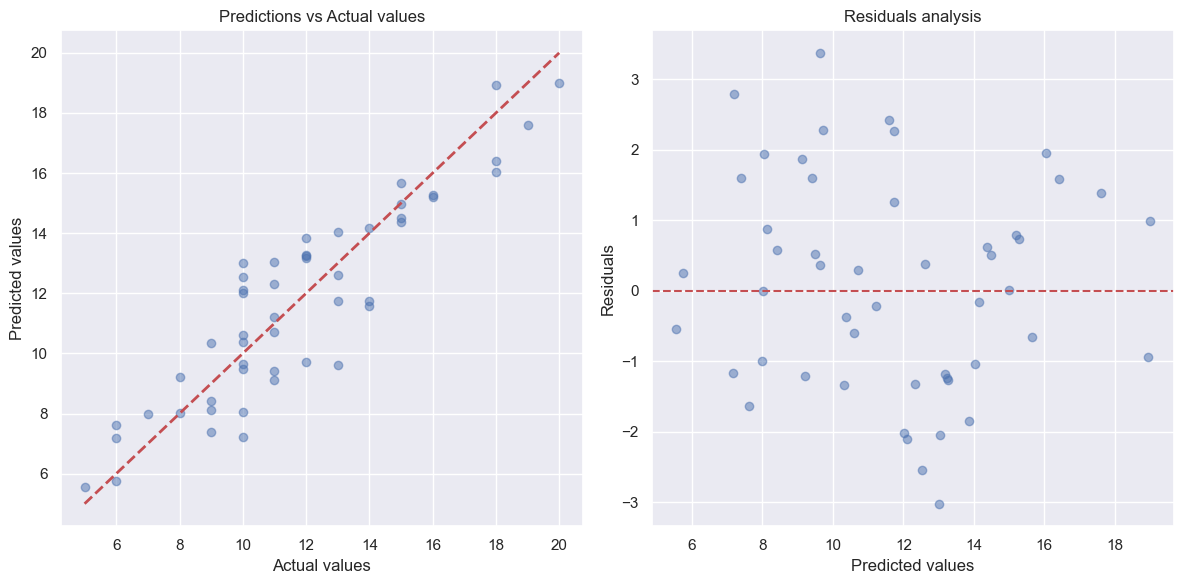

In [26]:
sns.set(rc={'figure.figsize': (11.7, 8.27)})
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Predictions vs Actual values')

plt.subplot(1, 2, 2)
residuals = y_test.values.flatten() - y_test_pred.flatten()
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals analysis')

plt.tight_layout()
plt.show()

Despite data limitations and model simplicity, satisfactory predictive effectiveness has been demonstrated. The model successfully identifies main patterns while maintaining balance between interpretability and predictive power.